In [63]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from backtrader.analyzers import returns

warnings.filterwarnings("ignore")

[*********************100%***********************]  1 of 1 completed


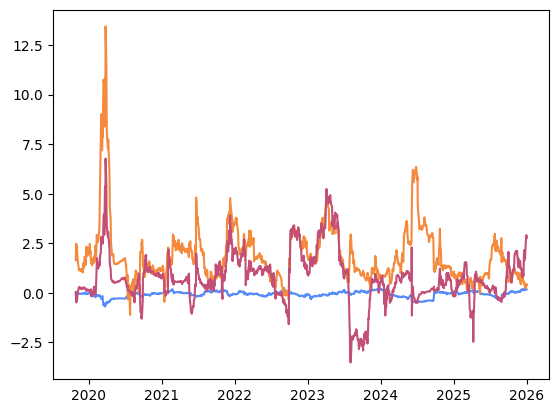

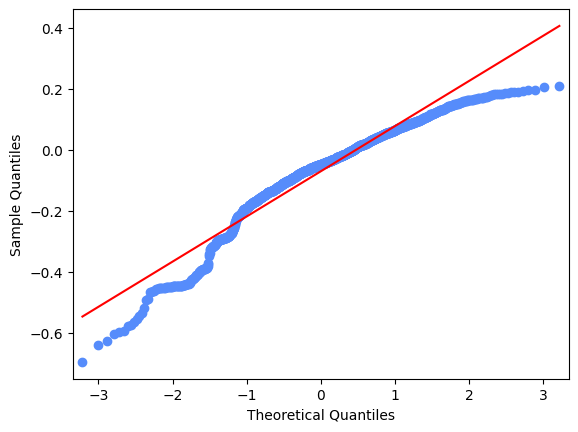

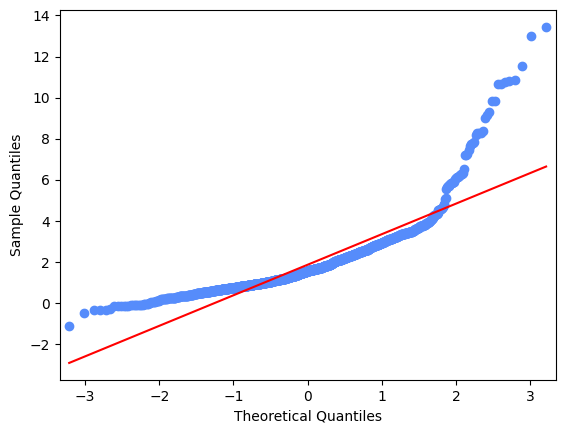

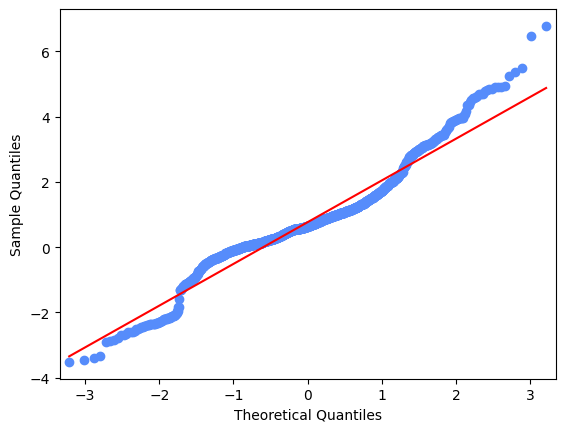

In [61]:
df = yf.download("^NSEI", start="2019-06-06",end= '2026-01-01',auto_adjust=False,multi_level_index=False)
df.drop(columns=['Close','High','Low','Open','Volume'], inplace=True)

df['returns'] = np.log(df['Adj Close']/df['Adj Close'].shift(1))
df['lag1'] = df['returns'].shift(1)
df['ma_20'] = df['returns'].rolling(20).mean().shift(1)
df["volatility_20"] = df['returns'].rolling(20).std().shift(1)
df.dropna(inplace=True)

x = df[['lag1','ma_20','volatility_20']]
y = df['returns']

from sklearn.linear_model import LinearRegression

window = 75
coef = []
pred = []
intercept = []
date = []

for i in range(window,len(df)):

    x_train = x.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    x_test = x.iloc[i:i+1]

    model = LinearRegression().fit(x_train, y_train)
    forecast = model.predict(x_test)

    pred.append(forecast[0])
    coef.append(model.coef_)
    intercept.append(model.intercept_)
    date.append(x_test.index[0])

coef_arr = np.array(coef)

results = pd.DataFrame({"prediction": pred,"coef_lag1": coef_arr[:, 0],
                        "coef_mean": coef_arr[:, 1],
                        "coef_std": coef_arr[:, 2],
                        "intercept":intercept}, index=date)
results['actual'] = df.loc[results.index,'returns']
results['residual'] = results['actual'] - results['prediction']
results = results[['actual','prediction','residual','coef_lag1','coef_mean','coef_std','intercept']]

plt.plot(results['coef_lag1'],label='lag1')
plt.plot(results['coef_mean'],label='mean')
plt.plot(results['coef_std'],label='std')
plt.show()

import statsmodels.api as sm
sm.qqplot(results['coef_lag1'], line='s')
plt.show()

sm.qqplot(results['coef_mean'], line='s')
plt.show()

sm.qqplot(results['coef_std'], line='s')
plt.show()

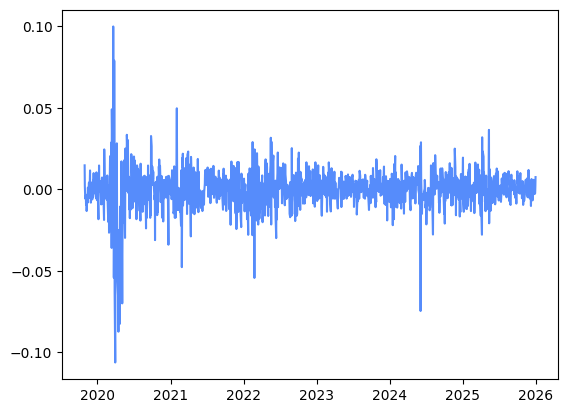

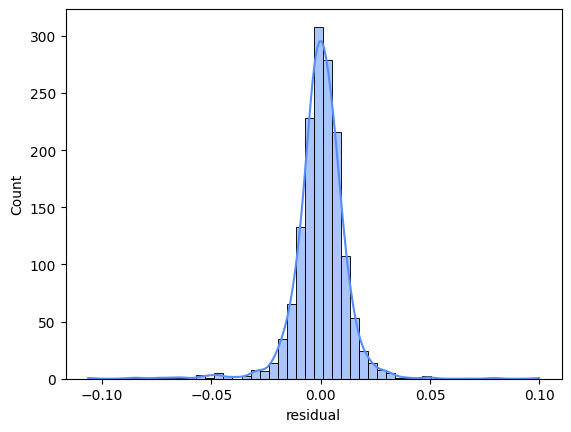

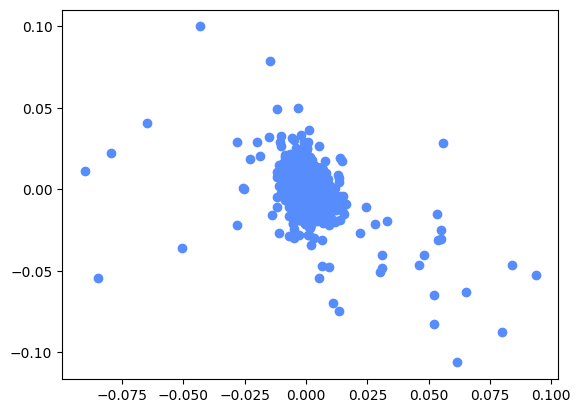

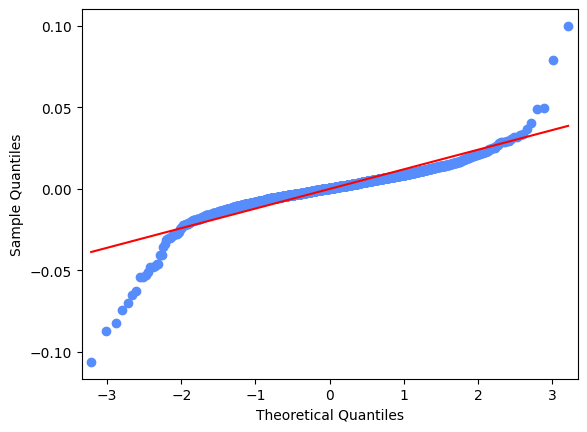

mean -0.000166284081259995


In [62]:
plt.plot(results['residual'],label='residual')
plt.show()

sns.histplot(results['residual'],kde =True,bins=50)
plt.show()

plt.scatter(results['prediction'],results['residual'])
plt.show()

sm.qqplot(results['residual'],line='s',label='residual')
plt.show()

print("mean",results['residual'].mean())

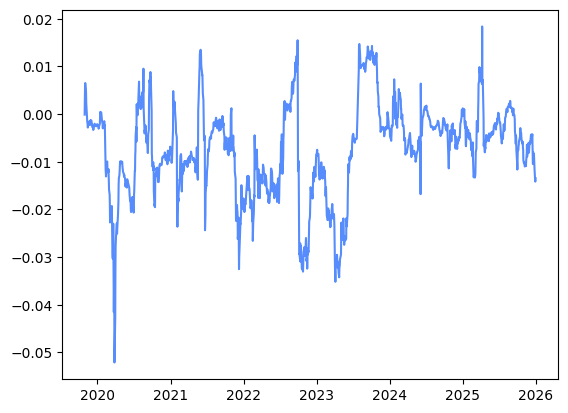

In [66]:
plt.plot(results['intercept'])
plt.show()